# Пользовательские свёрточные сети #

# Введение #

Теперь, когда вы познакомились со слоями, которые свёрточная сеть использует для извлечения признаков, пришло время собрать их вместе и построить собственную сеть!

# От простого к сложному #

В прошлых трёх уроках мы увидели, как свёрточные сети выполняют **извлечение признаков** с помощью трёх операций: **фильтрация**, **обнаружение** и **уплотнение**. Один раунд извлечения признаков может извлечь из изображения только относительно простые признаки — такие как простые линии или контрасты. Они слишком просты для решения большинства задач классификации. Вместо этого свёрточные сети повторяют этот процесс извлечения снова и снова, чтобы признаки становились всё более сложными и уточнёнными по мере продвижения вглубь сети.

<figure>
<img src="./img/VqmC1rm.png" alt="Признаки, извлечённые из изображения автомобиля — от простых к сложным." width=800>
</figure>

# Свёрточные блоки #

Сеть делает это, пропуская изображения через длинные цепочки **свёрточных блоков**, которые выполняют это извлечение.

<figure>
<img src="./img/pr8VwCZ.png" width="400" alt="Извлечение как последовательность блоков.">
</figure>

Эти свёрточные блоки представляют собой стопки слоёв `Conv2D` и `MaxPool2D`, роль которых в извлечении признаков мы изучили в прошлых уроках.

<figure>
<img src="./img/8D6IhEw.png" width="400" alt="Вид блока извлечения: свёртка, ReLU, подвыборка.">
</figure>

Каждый блок представляет собой один раунд извлечения. Компонуя такие блоки, свёрточная сеть может объединять и перекомбинировать полученные признаки, развивая их и адаптируя к решаемой задаче. Глубокая структура современных свёрточных сетей обеспечивает такую сложную инженерию признаков и во многом отвечает за их превосходную производительность.

# Пример — Проектирование свёрточной сети #

Давайте посмотрим, как определить глубокую свёрточную сеть, способную создавать сложные признаки. В этом примере мы создадим модель Keras `Sequential`, а затем обучим её на наборе данных Cars.

## Шаг 1 — Загрузка данных ##

Эта скрытая ячейка загружает данные.

In [20]:
# Импорты
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Воспроизводимость
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Настройки Matplotlib по умолчанию
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # чтобы очистить вывод ячеек

# '/tf/Lessons/4._Computer_Vision/img/'
# Загрузка обучающего и валидационного наборов
ds_train_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=32,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=32,
    shuffle=False,
)

# Конвейер данных
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


## Шаг 2 — Определение модели ##

Вот диаграмма модели, которую мы будем использовать:

<figure>
<img src="./img/U1VdoDJ.png" width="250" alt="Диаграмма свёрточной модели.">
</figure>

Теперь определим модель. Обратите внимание, что наша модель состоит из трёх блоков слоёв `Conv2D` и `MaxPool2D` (база), за которыми следует головная часть из полносвязных (`Dense`) слоёв. Мы можем перенести эту диаграмму почти напрямую в модель Keras `Sequential`, просто заполнив соответствующие параметры.

In [21]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    # Первый свёрточный блок
    layers.Conv2D(filters=32, kernel_size=5, activation="relu", padding='same',
                  # указываем размеры входа в первом слое
                  # [высота, ширина, цветовые каналы (RGB)]
                  input_shape=[128, 128, 3]),
    layers.MaxPool2D(),

    # Второй свёрточный блок
    layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Третий свёрточный блок
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Головная часть классификатора
    layers.Flatten(),
    layers.Dense(units=6, activation="relu"),
    layers.Dense(units=1, activation="sigmoid"),
])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_30 (Conv2D)          (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 64, 64, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_31 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 32, 32, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_32 (Conv2D)          (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 16, 16, 128)      

Обратите внимание, как количество фильтров удваивается от блока к блоку: 32, 64, 128. Это распространённый паттерн. Поскольку слой `MaxPool2D` уменьшает *размер* карт признаков, мы можем позволить себе увеличить их *количество*.

## Шаг 3 — Обучение ##

Мы можем обучить эту модель точно так же, как модель из Урока 1: скомпилировать её с оптимизатором, а также функцией потерь и метрикой, подходящими для бинарной классификации.

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # или 'val_accuracy'
    patience=3,          # ждём 3 эпохи без улучшения
    restore_best_weights=True,  # возвращаем лучшую модель
    verbose=0
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=40,
    callbacks=[early_stop],
    verbose=0,
)

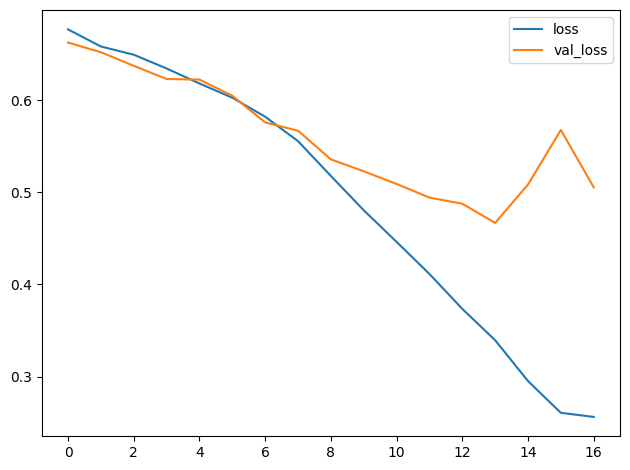

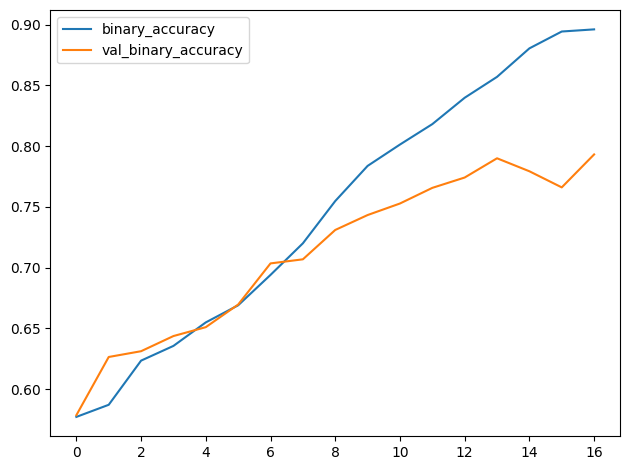

In [23]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

Эта модель намного меньше модели VGG16 из Урока 1 — всего 3 свёрточных слоя против 16 у VGG16. Тем не менее, она смогла довольно хорошо обучиться на этом наборе данных. Возможно, мы сможем ещё улучшить эту простую модель, добавив больше свёрточных слоёв, чтобы создать признаки, лучше адаптированные к набору данных. Именно это мы и попробуем сделать в упражнениях.

# Заключение #

В этом уроке вы узнали, как построить пользовательскую свёрточную сеть, состоящую из множества **свёрточных блоков** и способную выполнять сложную инженерию признаков.

# Ваша очередь #

В упражнениях вы создадите свёрточную сеть, которая покажет на этой задаче результат, не уступающий VGG16 — и всё это без предварительного обучения! [**Попробуйте сейчас!**](https://www.kaggle.com/kernels/fork/11989565)
---

*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*